In [14]:
import numpy as np
import matplotlib.pyplot as plt


In [15]:

# Parâmetros físicos (em unidades atômicas)
alpha = 1.0  # intensidade do potencial periódico
n_vals = np.array([-1, 0, 1])                  # G = 2πn, 3 planos de onda
G_vals = 2 * np.pi * n_vals
N = len(G_vals)

# Valores de k dentro da 1ª zona de Brillouin: -π < k ≤ π
k_vals = np.linspace(-np.pi, np.pi, 200, endpoint=False)
bands = np.zeros((len(k_vals), N))  # armazenar autovalores para cada k


In [16]:
# Loop sobre todos os valores de k
for i, k in enumerate(k_vals):
    delta_k = k - G_vals
    lambda_vals = delta_k**2  # energia cinética |k - G|^2

    # Monta Hamiltoniano tridiagonal
    H = np.zeros((N, N))
    for j in range(N):
        H[j, j] = lambda_vals[j]
        if j > 0:
            H[j, j - 1] = alpha
        if j < N - 1:
            H[j, j + 1] = alpha

    # Diagonaliza H(k)
    eigvals = np.linalg.eigvalsh(H)
    bands[i, :] = eigvals  # salva autovalores ordenados


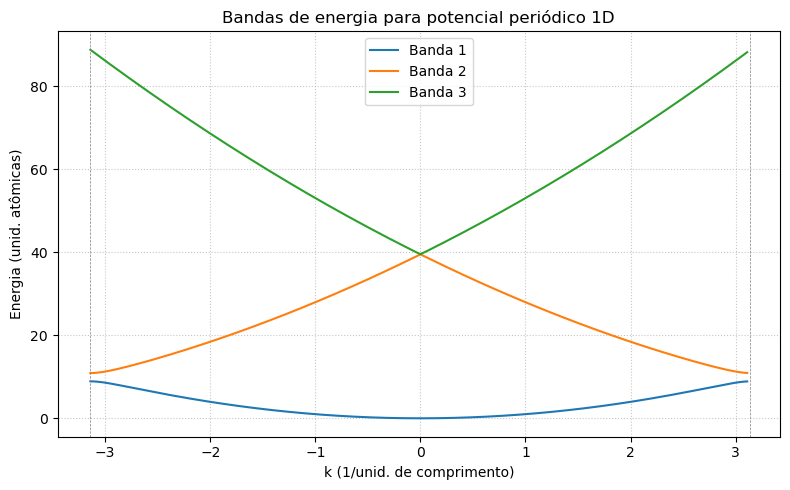

In [17]:
# Plotando o diagrama de bandas
plt.figure(figsize=(8, 5))
for n in range(N):
    plt.plot(k_vals, bands[:, n], label=f"Banda {n+1}")
plt.title("Bandas de energia para potencial periódico 1D")
plt.xlabel("k (1/unid. de comprimento)")
plt.ylabel("Energia (unid. atômicas)")
plt.axvline(x=-np.pi, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(x=np.pi, color='gray', linestyle='--', linewidth=0.5)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
lambda_matrix = np.zeros((len(G_vals), len(k_vals)))